In [1]:
import numpy as np
import tensorflow as tf

2026-09-28 20:37:46.152593: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [10]:
Data_set = np.loadtxt("../dataset/ThoraricSurgery.csv", delimiter=",")

x_data = Data_set[:, 0:17].astype(np.float32)
y_data = Data_set[:, [17]].astype(np.float32)

# 은닉층 가중치(2x30)와 편향(30) 정의
W1 = tf.Variable(tf.random.normal([17, 30]))
b1 = tf.Variable(tf.random.normal([30]))

# 출력층 가중치(30x1)와 편향(1) 정의
W2 = tf.Variable(tf.random.normal([30, 1]))
b2 = tf.Variable(tf.random.normal([1]))

# 활성화 함수 (sigmoid)
def sigmoid(x):
    return 1 / (1 + tf.exp(-x))

# 다층 퍼셉트론 정의 (은닉층 -> 출력층)
def perceptron(x):
    # 은닉층 연산
    hidden = sigmoid(tf.matmul(x, W1) + b1)
    # 출력층 연산
    return sigmoid(tf.matmul(hidden, W2) + b2)

# 손실 함수 정의 (이진 크로스 엔트로피)
def loss_fn(y_true, y_pred):
    return tf.reduce_mean(-(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred)))

# optimizers 정의 (SGD)
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)

# 결과를 0 또는 1로 변환하는 함수 정의
def binary_output(x):
    return int(x.numpy()[0][0] > 0.5)

# 정확도 계산 함수 정의
def accuracy(y_true, y_pred):
    correct_prediction = tf.equal(tf.cast(y_pred > 0.5, tf.float32), y_true)
    return tf.reduce_mean(tf.cast(correct_prediction, tf.float32))

# 학습 과정
for epoch in range(10000):
    with tf.GradientTape() as tape:
        pred = perceptron(x_data)
        loss = loss_fn(y_data, pred)
    gradients = tape.gradient(loss, [W1, b1, W2, b2])
    optimizer.apply_gradients(zip(gradients, [W1, b1, W2, b2]))

    # 500번마다 학습 과정 출력
    if (epoch + 1) % 1000 == 0:
        W1_val = np.squeeze(W1.numpy())
        b1_val = np.squeeze(b1.numpy())
        W2_val = np.squeeze(W2.numpy())
        b2_val = np.squeeze(b2.numpy())
        print(f"step = {epoch+1}, cost = {loss.numpy():.9f}")
        print(f"W1 = {W1_val}, b1 = {b1_val}")
        print(f"W2 = {W2_val}, b2 = {b2_val}")
        print("----------------------------------------")

# 학습 결과 출력
for input_data in x_data:
    prediction = perceptron(np.array([input_data], dtype=np.float32))
    print(f"입력: {input_data.tolist()}, 예측(확률): {prediction.numpy()[0][0]:.4f}, 예측(이진): {binary_output(prediction)}")

# 정확도 출력
predictions = perceptron(x_data)
acc = accuracy(y_data, predictions)
print(f"정확도: {acc.numpy():.4f}")

step = 1000, cost = nan
W1 = [[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan 

# 21h15~

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

Data_set = np.loadtxt("../dataset/ThoraricSurgery.csv", delimiter=",")

X = Data_set[:, 0:17]
Y = Data_set[:, 17]

model = Sequential()
model.add(Input(shape=(17,)))
model.add(Dense(30, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X, Y, epochs=30, batch_size=10)

print("\n Accuracy: %.4f" % (model.evaluate(X, Y)[1]))

input_data = np.array([[132,2,2.12,1.72,1,0,0,0,0,0,12,0,0,0,1,0,74]], dtype=np.float32)

prediction = model.predict(input_data)
print(prediction)

Epoch 1/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8340 - loss: 0.5068
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8511 - loss: 0.4282 
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8511 - loss: 0.4212  
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8511 - loss: 0.4199
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8511 - loss: 0.4194 
Epoch 6/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8511 - loss: 0.4191   
Epoch 7/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8511 - loss: 0.4186 
Epoch 8/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8511 - loss: 0.4184
Epoch 9/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8511 - loss: 0.4182  
Epoch 10/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8511 - loss: 0.4180
Epoch 11/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8511 - loss: 0.4178
Epoch 12/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc

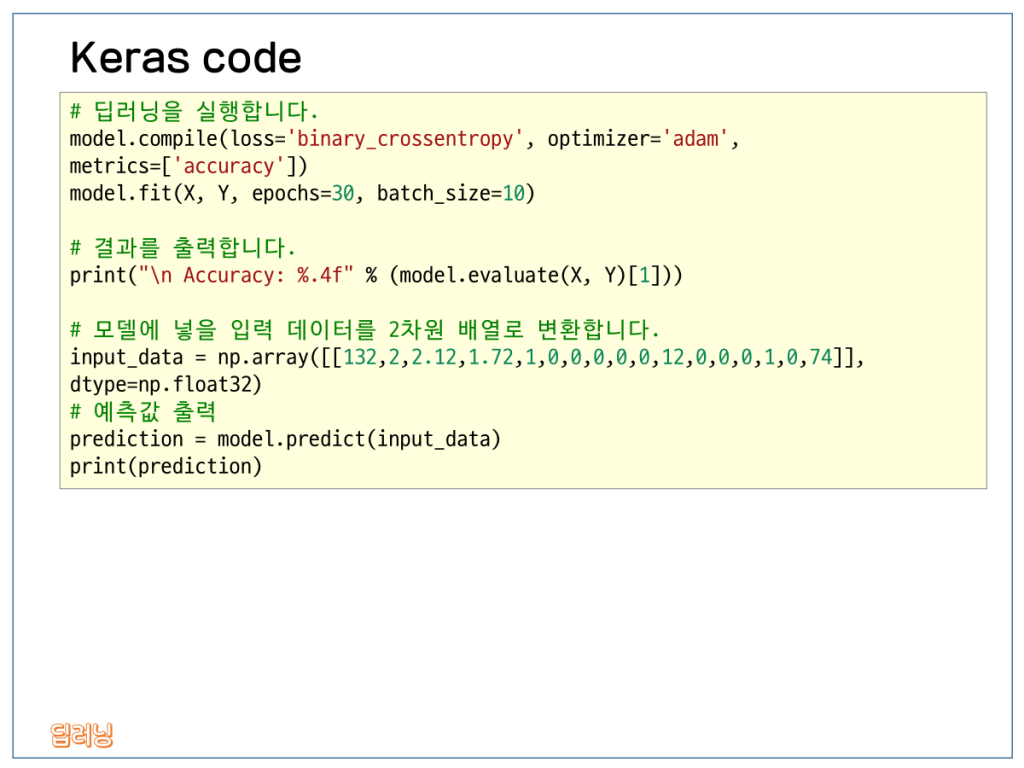

## 22h~ 너무 졸려서 수업 제대로 못 들음 ㅠㅠ 엎드려서 잠..

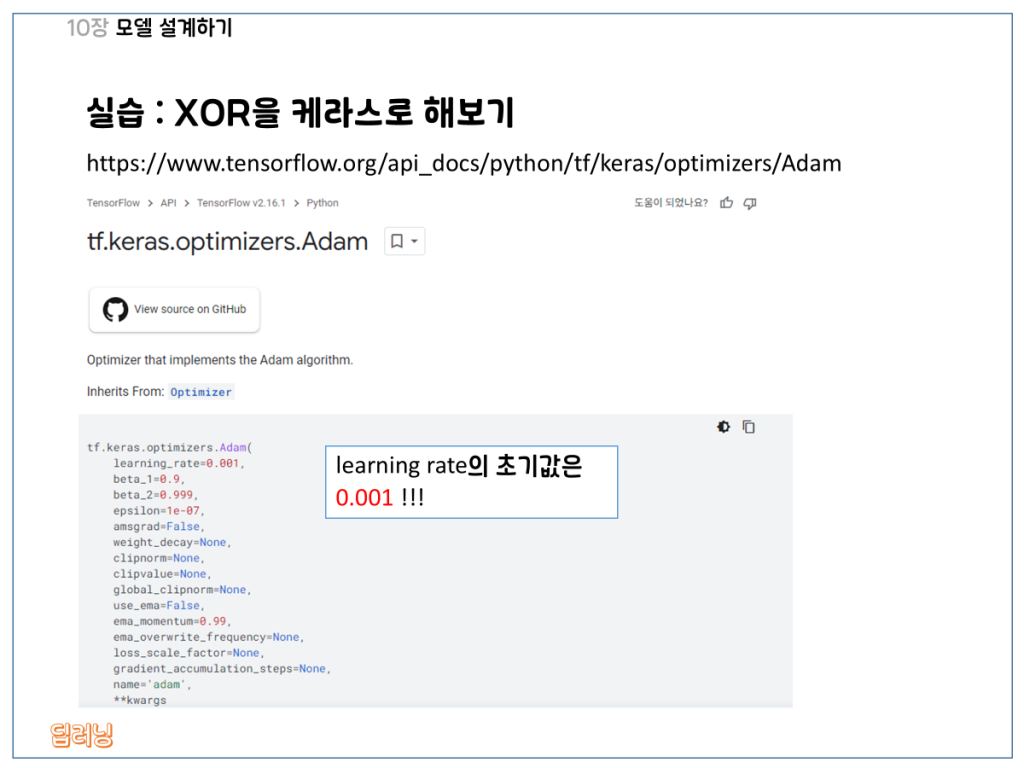


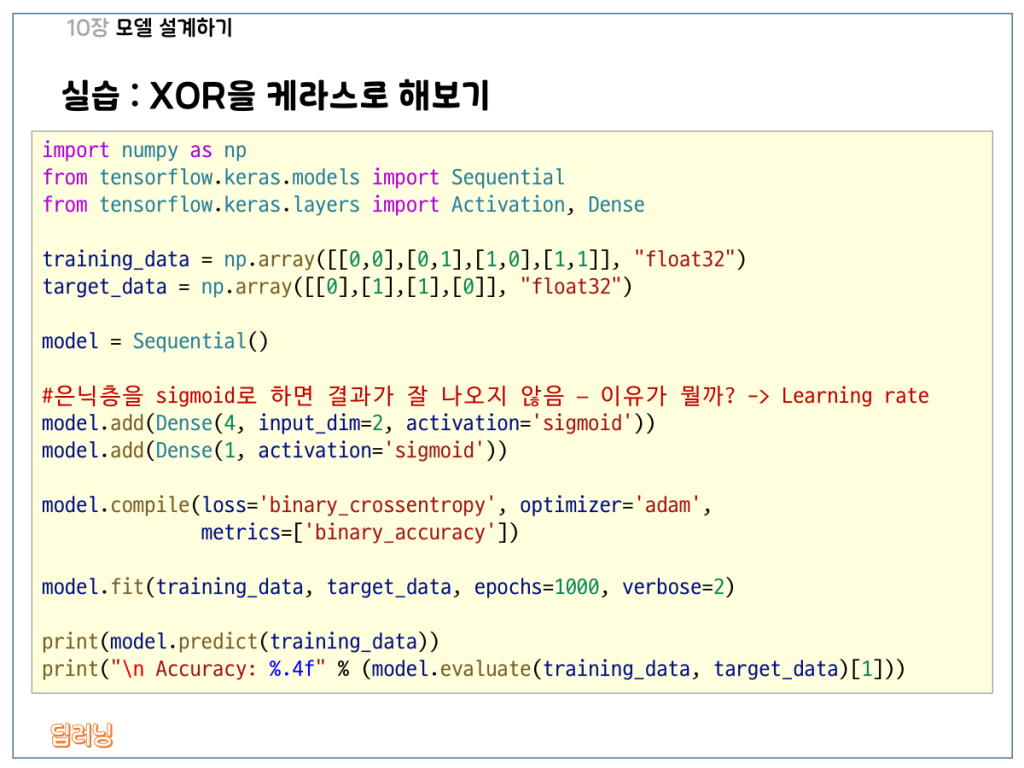

방법1

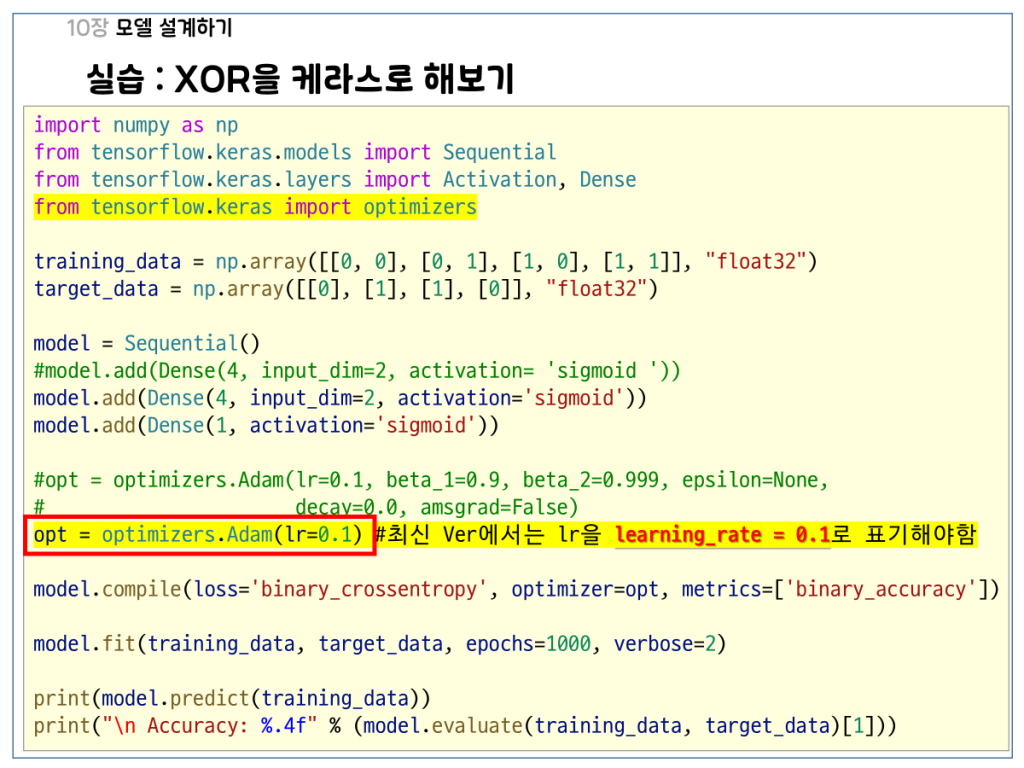

방법2

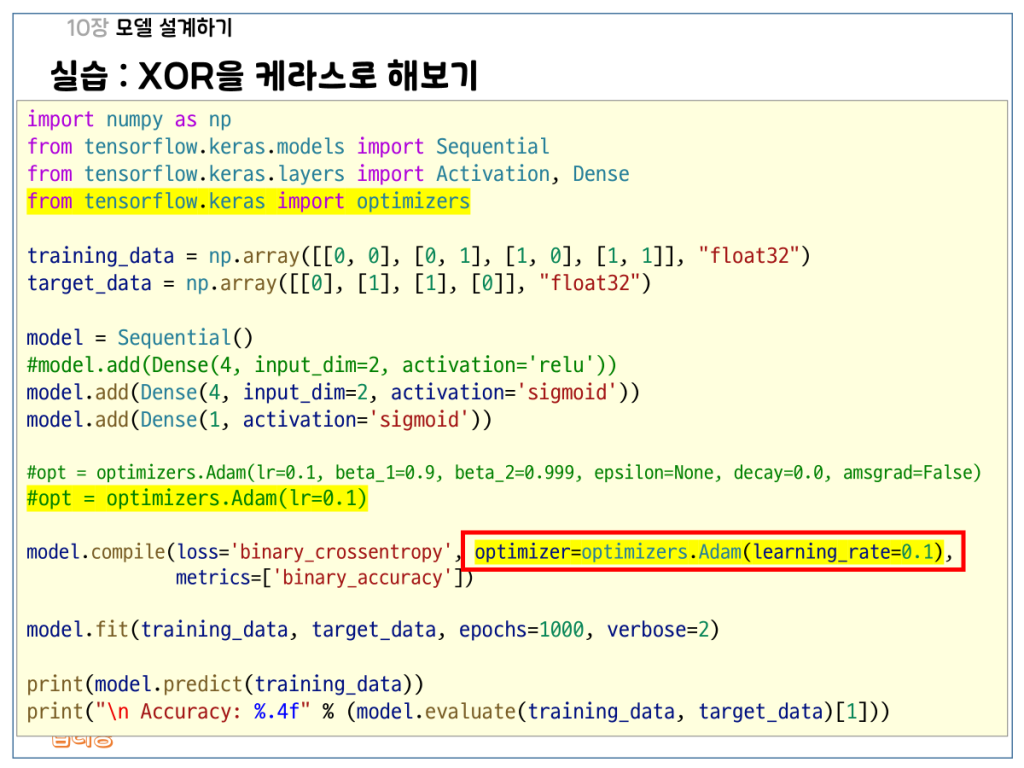

# 2026.9.29(화) 19h

### 19h20~ 당뇨 데이터를 활용한 당뇨 예측을 Keras로 해보기 실습

In [16]:
Data_set = np.loadtxt("../dataset/data-03-diabetes.csv", delimiter=",")

X = Data_set[:, 0:8]
Y = Data_set[:, 8]

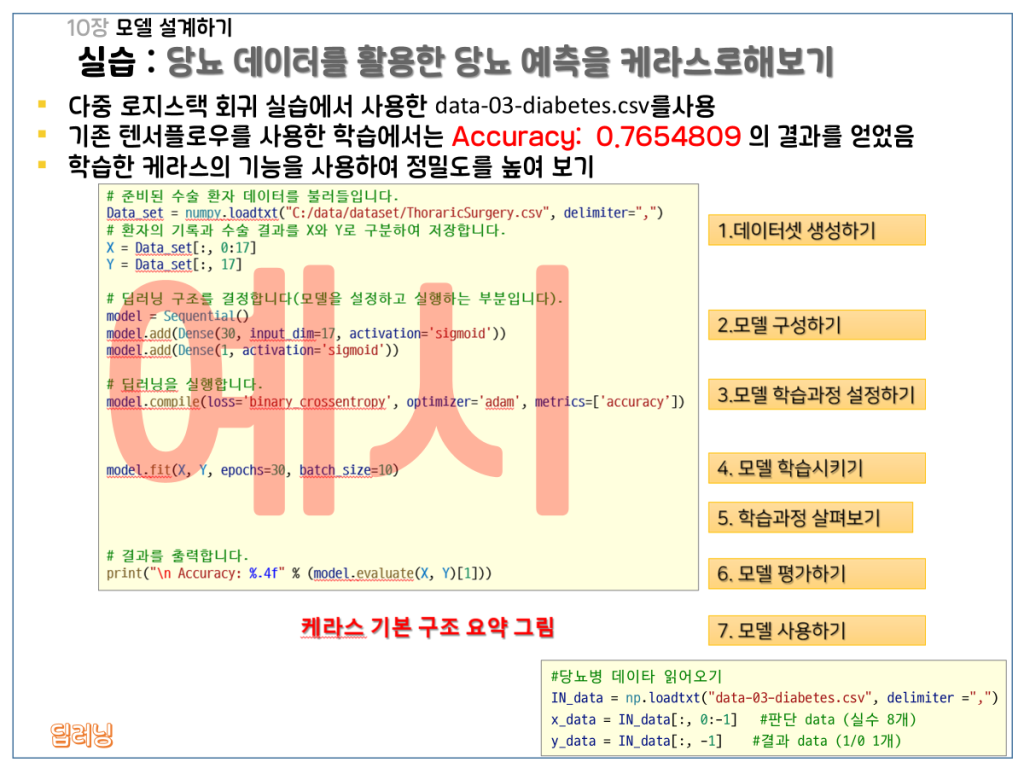

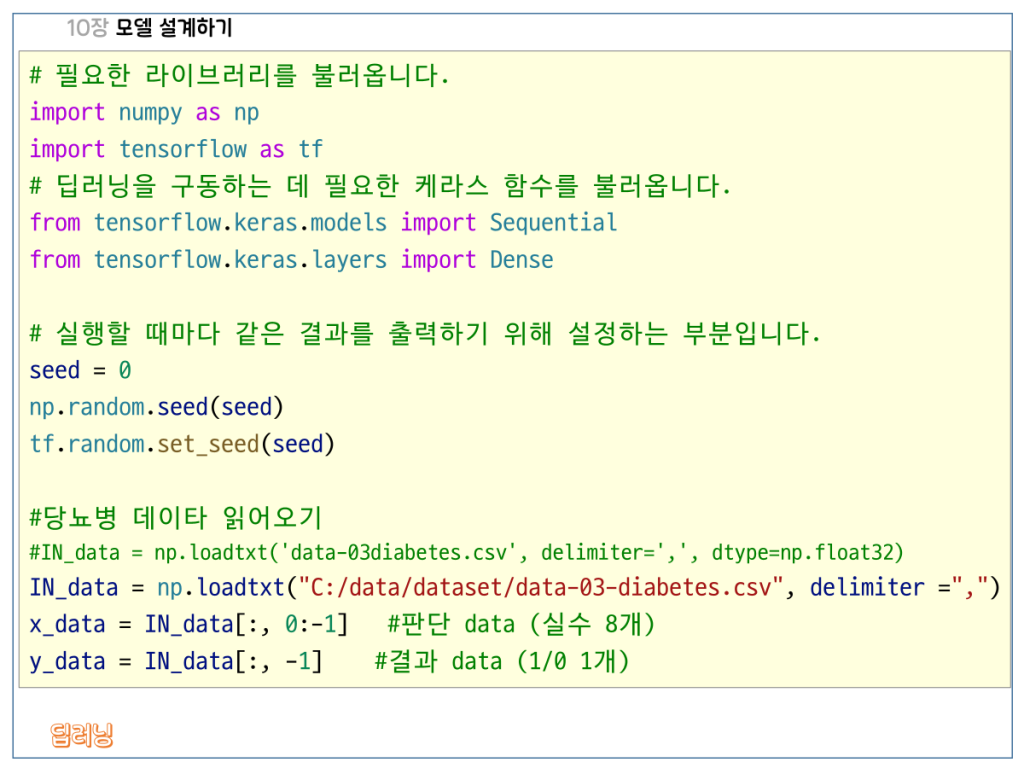

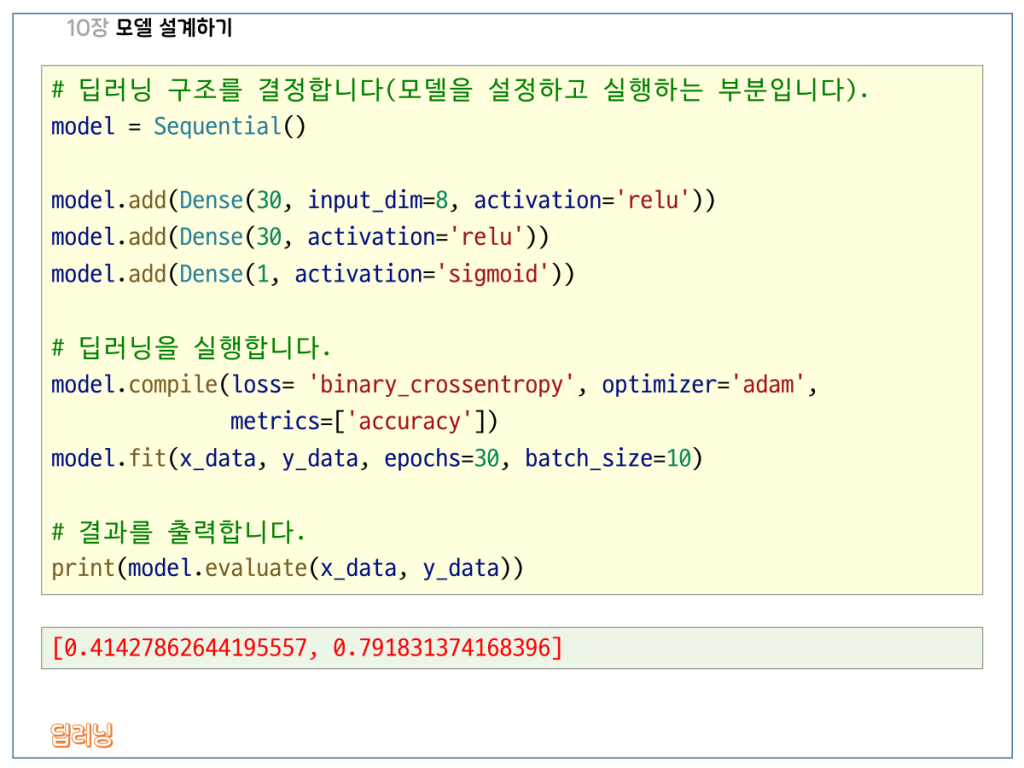

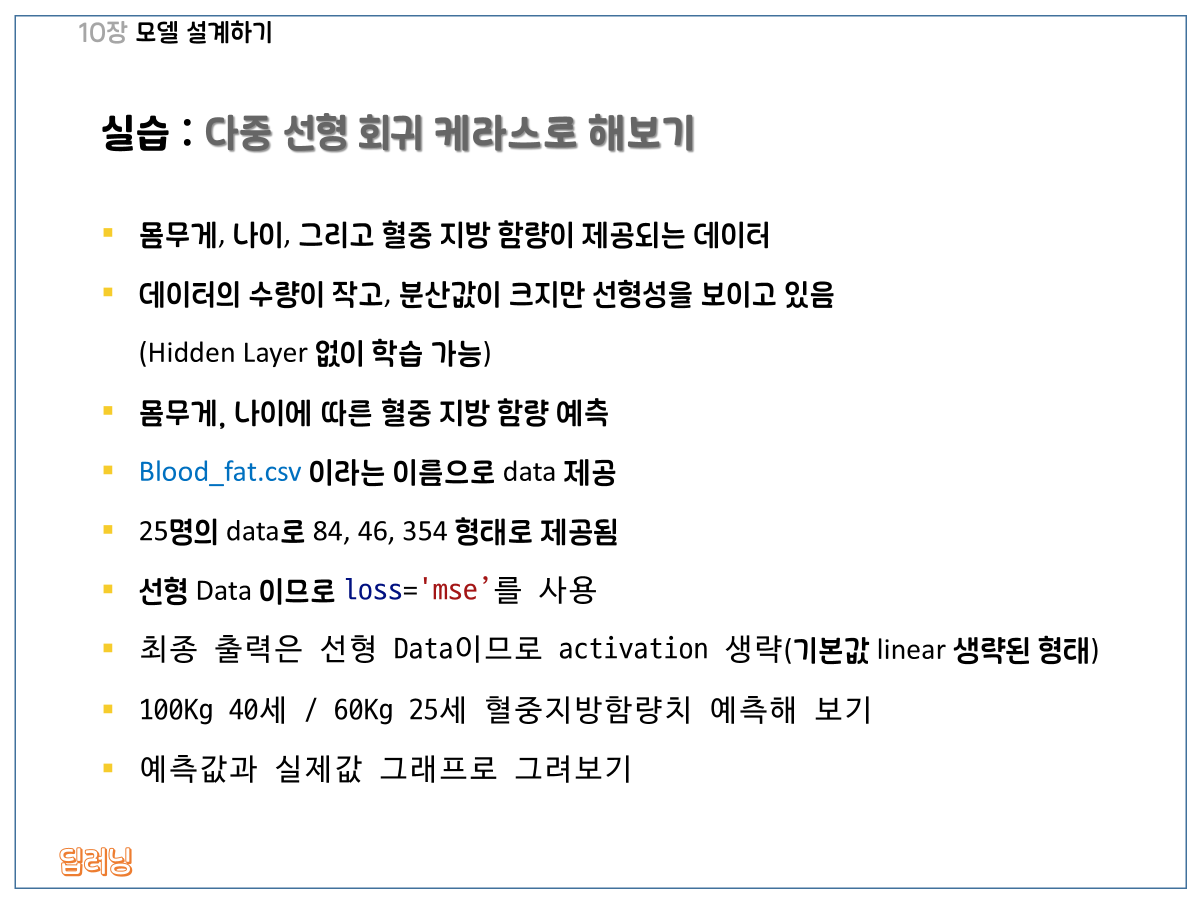

In [27]:
# 20h15~ 내가 작성해본 코드
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

Data_set = np.loadtxt("../dataset/Blood_fat.csv", delimiter=",")

X = Data_set[:, 0:-1]
Y = Data_set[:, -1]

model = Sequential()
model.add(Input(shape=(2,)))
model.add(Dense(1))
model.add(Dense(1))

model.compile(loss='mse', optimizer='adam', metrics=['mae'])
model.fit(X, Y, epochs=100, batch_size=10)

print("\n Accuracy: %.4f" % (model.evaluate(X, Y)[1]))

input_data = np.array([[100,40],[60,25]], dtype=np.float32)

prediction = model.predict(input_data)
print(prediction)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - loss: 82267.4688 - mae: 277.4572
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 82039.4141 - mae: 277.0574
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 81810.9688 - mae: 276.6564 
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 81581.7109 - mae: 276.2534
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 81351.6016 - mae: 275.8482
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 81120.5938 - mae: 275.4409 
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - loss: 80888.6719 - mae: 275.0315
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 80655.8125 - mae: 274.6197
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 80421.9922 - mae: 274.2056
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 80187.1797 - mae: 273.7892 
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 79951.3828 - mae: 273.3702
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss:

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

Data_set = np.loadtxt("../dataset/Blood_fat.csv", delimiter=",")

X = Data_set[:, 0:-1]
Y = Data_set[:, -1]

model = Sequential()
model.add(Input(shape=(2,)))
model.add(Dense(1))
model.add(Dense(1))

model.compile(loss='mse', optimizer='adam', metrics=['mae'])
model.fit(X, Y, epochs=100, batch_size=10)

print("\n Accuracy: %.4f" % (model.evaluate(X, Y)[1]))

input_data = np.array([[100,40],[60,25]], dtype=np.float32)

prediction = model.predict(input_data)
print(prediction)

In [28]:
import tensorflow as tf
import numpy as np

# XOR 데이터셋
x = np.array([[0,0], [0,1], [1,0], [1,1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

# 깊은 MLP 모델 함수
def build_model(activation='sigmoid'):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(2,)))
    for _ in range(6):  # 깊은 구조
        model.add(tf.keras.layers.Dense(10, activation=activation))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    
    model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# sigmoid 실험
print("🔹 sigmoid로 학습 (기울기 소실 기대)")
model_sigmoid = build_model('sigmoid')
model_sigmoid.fit(x, y, epochs=2000, verbose=0)
loss_sig, acc_sig = model_sigmoid.evaluate(x, y)
print(f"Sigmoid 결과: 정확도={acc_sig:.2f}")

# relu 실험
print("\n🔹 relu로 학습 (기울기 소실 없음)")
model_relu = build_model('relu')
model_relu.fit(x, y, epochs=2000, verbose=0)
loss_relu, acc_relu = model_relu.evaluate(x, y)
print(f"ReLU 결과: 정확도={acc_relu:.2f}")

🔹 sigmoid로 학습 (기울기 소실 기대)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 751ms/step - accuracy: 0.5000 - loss: 0.6931
Sigmoid 결과: 정확도=0.50

🔹 relu로 학습 (기울기 소실 없음)
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 1.7199e-04
ReLU 결과: 정확도=1.00
